In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
meal_gap = pd.read_csv("../data/Meal_Gap_2019.csv")

In [3]:
meal_gap.head()

,FIPS,State,County,pctFoodInsecure,numFoodInsecure,pctBlackFoodInsecure,pctLatineFoodInsecure,pctWhiteFoodInsecure,SNAPthreshold,pctFIbelowSNAP,pctFIaboveSNAP,pctKidsFoodInsecure,numKidsFoodInsecure,pctKidsIncomeBelow185,pctKidsIncomeAbove185,costPerMeal,weeklyFoodBudget,weeklyBudgetFoodInsecureByPop,rangeRuralUrban,USstateRegion
0,1001,AL,Autauga County,0.157,8670.0,0.26,NaN,0.12,1.3,0.486,0.514,0.196,2590.0,0.69,0.31,3.00,16.88,4439000.0,2.0,South
1,1003,AL,Baldwin County,0.134,28590.0,0.26,0.10,0.11,1.3,0.391,0.609,0.144,6680.0,0.79,0.21,3.66,20.63,17895000.0,3.0,South
2,1005,AL,Barbour County,0.207,5250.0,0.34,NaN,0.14,1.3,0.663,0.337,0.324,1720.0,0.72,0.28,3.11,17.51,2788000.0,6.0,South
3,1007,AL,Bibb County,0.163,3680.0,0.28,NaN,0.14,1.3,0.478,0.522,0.218,1010.0,0.89,0.11,2.96,16.68,1861000.0,1.0,South
4,1009,AL,Blount County,0.145,8380.0,0.14,0.11,0.12,1.3,0.462,0.538,0.154,2060.0,1.00,0.00,3.04,17.14,4357000.0,1.0,South


## Top 20 and bottom 20 counties for food insecurity

In [4]:
bar_chart_data_top_10 = meal_gap[['County', 'pctFoodInsecure']].sort_values(by='pctFoodInsecure', ascending=False)[:10]
bar_chart_data_top_10

,County,pctFoodInsecure
1428,Issaquena County,0.294
81,Kusilvak Census Area,0.286
2412,Oglala Lakota County,0.277
2421,Todd County,0.275
1040,Harlan County,0.266
1426,Holmes County,0.262
1058,Leslie County,0.259
1005,Breathitt County,0.253
2408,Mellette County,0.250
999,Bell County,0.248


In [5]:
bar_chart_data_top_10['County'] = bar_chart_data_top_10['County'].str[:-6]
bar_chart_data_top_10

,County,pctFoodInsecure
1428,Issaquena,0.294
81,Kusilvak Censu,0.286
2412,Oglala Lakota,0.277
2421,Todd,0.275
1040,Harlan,0.266
1426,Holmes,0.262
1058,Leslie,0.259
1005,Breathitt,0.253
2408,Mellette,0.250
999,Bell,0.248


In [6]:
bar_chart_data_top_10['County'] = bar_chart_data_top_10['County'].replace('Kusilvak Censu', 'Kusilvak Census')

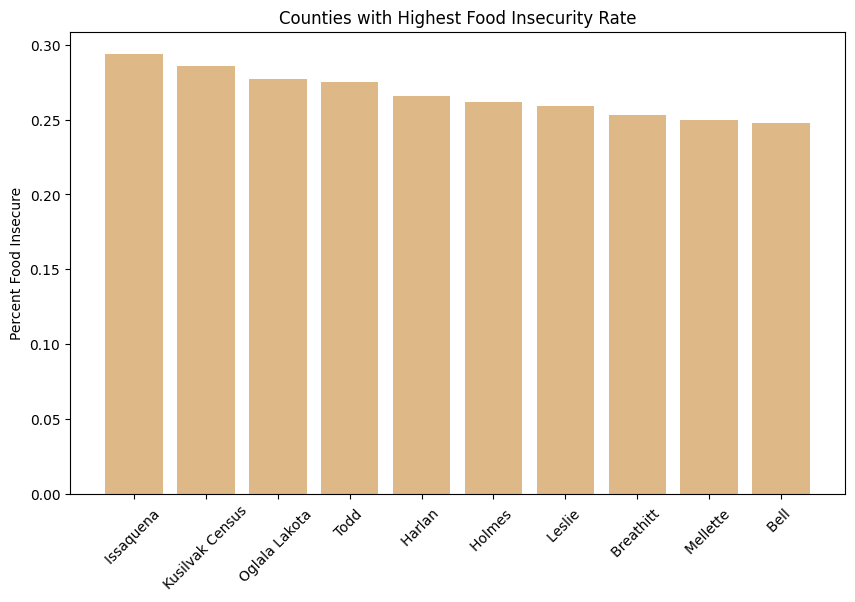

In [7]:
plt.figure(figsize=(10, 6))
plt.bar(bar_chart_data_top_10['County'], bar_chart_data_top_10['pctFoodInsecure'], color='burlywood')
plt.xticks(rotation=45)
plt.ylabel('Percent Food Insecure')
plt.title('Counties with Highest Food Insecurity Rate')
plt.savefig('../visualizations/High_Food_Insecurity_Rates.png')
plt.show()

In [52]:
top_10_with_state = meal_gap[['County', 'pctFoodInsecure', 'State']].sort_values(by='pctFoodInsecure', ascending=False)[:10]
top_10_with_state

,County,pctFoodInsecure,State
1428,Issaquena County,0.294,MS
81,Kusilvak Census Area,0.286,AK
2412,Oglala Lakota County,0.277,SD
2421,Todd County,0.275,SD
1040,Harlan County,0.266,KY
1426,Holmes County,0.262,MS
1058,Leslie County,0.259,KY
1005,Breathitt County,0.253,KY
2408,Mellette County,0.250,SD
1432,Jefferson County,0.248,MS


In [8]:
bar_chart_data_bottom_10 = meal_gap[['County', 'pctFoodInsecure']].sort_values(by='pctFoodInsecure')[:10]
bar_chart_data_bottom_10

,County,pctFoodInsecure
2035,Steele County,0.029
2027,Renville County,0.031
1996,Burke County,0.032
2000,Dickey County,0.034
2030,Sargent County,0.038
2872,Loudoun County,0.040
1995,Bowman County,0.041
2013,Logan County,0.041
641,Kendall County,0.042
2002,Dunn County,0.044


In [9]:
bar_chart_data_bottom_10['County'] = bar_chart_data_bottom_10['County'].str[:-6]
bar_chart_data_bottom_10

,County,pctFoodInsecure
2035,Steele,0.029
2027,Renville,0.031
1996,Burke,0.032
2000,Dickey,0.034
2030,Sargent,0.038
2872,Loudoun,0.040
1995,Bowman,0.041
2013,Logan,0.041
641,Kendall,0.042
2002,Dunn,0.044


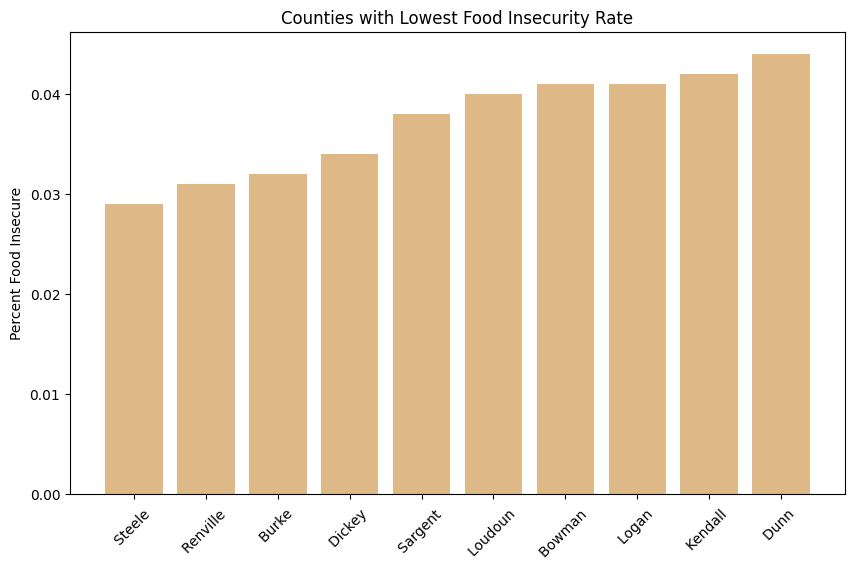

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(bar_chart_data_bottom_10['County'], bar_chart_data_bottom_10['pctFoodInsecure'], color='burlywood')
plt.xticks(rotation=45)
plt.ylabel('Percent Food Insecure')
plt.title('Counties with Lowest Food Insecurity Rate')
plt.savefig('../visualizations/Low_Food_Insecurity_Rates.png')
plt.show()

## Food insecurity by state

In [8]:
state_insecurity = meal_gap[['State', 'pctFoodInsecure']].groupby('State').agg('mean').reset_index().sort_values(by='pctFoodInsecure', ascending=False).iloc[:20]
state_insecurity.head()

,State,pctFoodInsecure
25,MS,0.192963
2,AR,0.174320
1,AL,0.168239
17,KY,0.164075
18,LA,0.161297


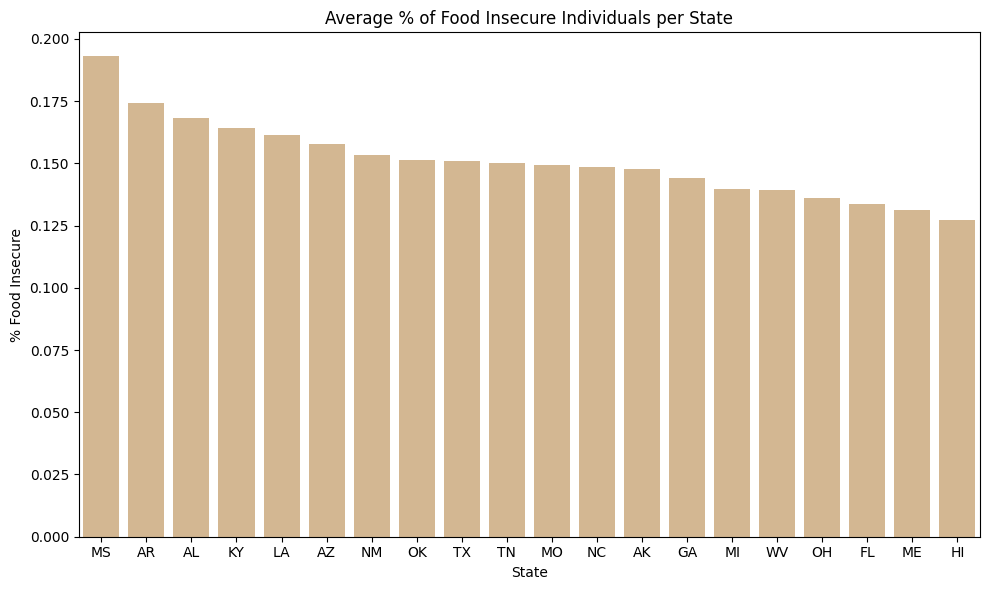

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(data=state_insecurity, x='State', y='pctFoodInsecure', color='burlywood')
plt.title('Average % of Food Insecure Individuals per State')
plt.xlabel('State')
plt.ylabel('% Food Insecure')
plt.tight_layout()
plt.savefig('../visualizations/Average_Food_Insecurity_Rate_State.png')
plt.show()

## Rural/urban continuum code 

In [36]:
urban_rural = meal_gap['rangeRuralUrban'].value_counts().sort_index()
urban_rural

rangeRuralUrban
1.0    432
2.0    378
3.0    356
4.0    214
5.0     92
6.0    593
7.0    433
8.0    220
9.0    424
Name: count, dtype: int64

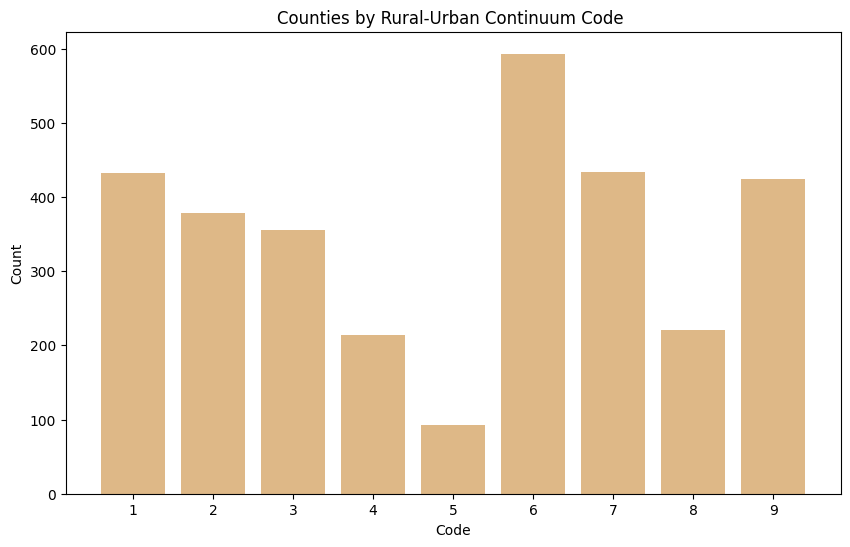

In [54]:
plt.figure(figsize=(10, 6))
plt.bar(list(urban_rural.index), urban_rural.values, color='burlywood')
plt.title('Counties by Rural-Urban Continuum Code ')
plt.xticks(list(range(1, 10)))
plt.xlabel('Code')
plt.ylabel('Count')
plt.savefig('../visualizations/Rural_Urban_Continuum_Code.png')
plt.show()